In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt

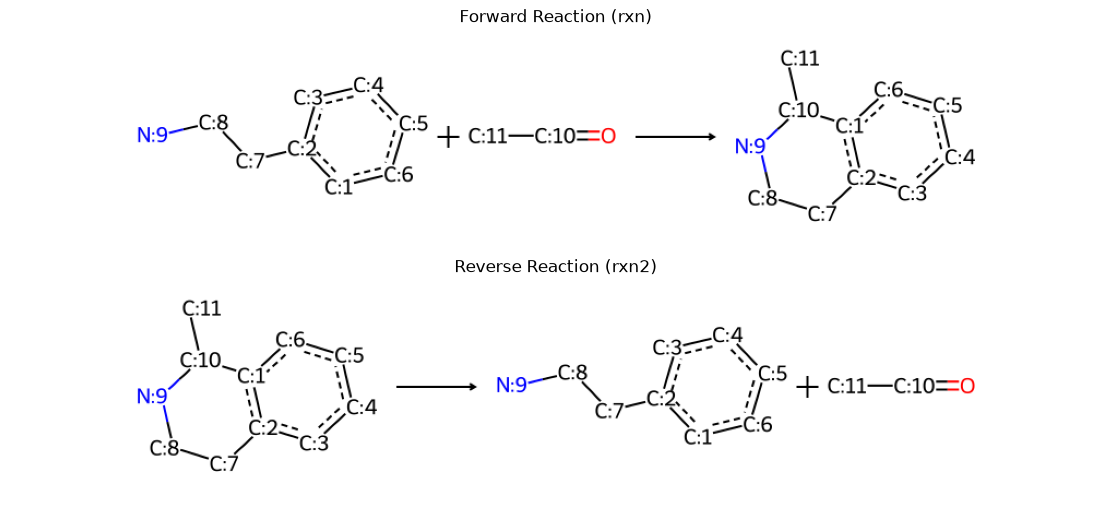

In [2]:
# 逆向反应
rxn = AllChem.ReactionFromSmarts('[cH1:1]1:[c:2](-[CH2:7]-[CH2:8]-[NH2:9]):[c:3]:[c:4]:[c:5]:[c:6]:1.[#6:11]-[CH1;R0:10]=[OD1]>>[c:1]12:[c:2](-[CH2:7]-[CH2:8]-[NH1:9]-[C:10]-2(-[#6:11])):[c:3]:[c:4]:[c:5]:[c:6]:1')

# 将反应物和产物模版对换 
rxn2 = AllChem.ChemicalReaction()
for i in range(rxn.GetNumReactantTemplates()):
    rxn2.AddProductTemplate(rxn.GetReactantTemplate(i))
for i in range(rxn.GetNumProductTemplates()):
    rxn2.AddReactantTemplate(rxn.GetProductTemplate(i))
rxn2.Initialize()

# subImgSize 是每个反应分区的尺寸，过大的宽度会在整张图两侧产生大量留白
img = Draw.ReactionToImage(rxn, subImgSize=(250, 200))
img2 = Draw.ReactionToImage(rxn2, subImgSize=(250, 200))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), constrained_layout=True)
for ax, reaction_img, title in zip(
    axes,
    [img, img2],
    ['Forward Reaction (rxn)', 'Reverse Reaction (rxn2)'],
):
    ax.imshow(reaction_img)
    ax.set_title(title, pad=4)
    ax.axis('off')

plt.show()

In [ ]:
# 反应指纹描述断键成键
from rdkit.Chem import rdChemReactions
from rdkit.Chem import DataStructs

# 不同环境的C=O形成
rxn1 = rdChemReactions.ReactionFromSmarts('CCCO>>CCC=O')
rxn2 = rdChemReactions.ReactionFromSmarts('CC(O)C>>CC(=O)C')
rxn3 = rdChemReactions.ReactionFromSmarts('NCCO>>NCC=O')

# 生成反应指纹=产物指纹-反应物指纹
fp1 = rdChemReactions.CreateDifferenceFingerprintForReaction(rxn1)
fp2 = rdChemReactions.CreateDifferenceFingerprintForReaction(rxn2)
fp3 = rdChemReactions.CreateDifferenceFingerprintForReaction(rxn3)

# 反应2是中间羟基氧化，反应1和3差别在末端氨基
print(DataStructs.TanimotoSimilarity(fp1,fp2))
print(DataStructs.TanimotoSimilarity(fp2,fp3))
print(DataStructs.TanimotoSimilarity(fp1,fp3)) 

0.0
0.0
0.42857142857142855
